# Diamond Price Prediction — Exploratory Data Analysis

We explore the classic **ggplot2 diamonds** dataset (~54k diamonds with their 4 Cs and physical dimensions) to find which features drive price.

**Dataset**: 53,940 diamonds, 9 features (carat, cut, color, clarity, depth, table, x, y, z) and the regression target `price` (USD).

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

%matplotlib inline

## 2. Load Data

In [2]:
df = pd.read_csv("data/diamonds.csv")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (53940, 10)


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


**Glossary** (the 4 Cs and dimensions):
- `carat` — mass of the diamond (1 carat = 0.2 g)
- `cut` — quality of the cut (Fair < Good < Very Good < Premium < Ideal)
- `color` — D (best, colorless) → J (worst, light yellow)
- `clarity` — I1 (worst) < SI2 < SI1 < VS2 < VS1 < VVS2 < VVS1 < IF (best)
- `depth` — total depth percentage = z / mean(x,y) × 100
- `table` — width of the top of the diamond relative to widest point
- `x`, `y`, `z` — length / width / depth in mm

## 3. Dataset Overview

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB


In [4]:
df.describe(include='all').round(2)

,carat,cut,color,clarity,depth,table,price,x,y,z
count,53940.00,53940,53940,53940,53940.00,53940.00,53940.00,53940.00,53940.00,53940.00
unique,NaN,5,7,8,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Ideal,G,SI1,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,21551,11292,13065,NaN,NaN,NaN,NaN,NaN,NaN
mean,0.80,NaN,NaN,NaN,61.75,57.46,3932.80,5.73,5.73,3.54
std,0.47,NaN,NaN,NaN,1.43,2.23,3989.44,1.12,1.14,0.71
min,0.20,NaN,NaN,NaN,43.00,43.00,326.00,0.00,0.00,0.00
25%,0.40,NaN,NaN,NaN,61.00,56.00,950.00,4.71,4.72,2.91
50%,0.70,NaN,NaN,NaN,61.80,57.00,2401.00,5.70,5.71,3.53
75%,1.04,NaN,NaN,NaN,62.50,59.00,5324.25,6.54,6.54,4.04


In [5]:
print(f"Duplicate rows : {df.duplicated().sum()}")
print(f"\nCategorical levels:")
for c in ["cut","color","clarity"]:
    print(f"  {c}: {df[c].value_counts().to_dict()}")

Duplicate rows : 146

Categorical levels:
  cut: {'Ideal': 21551, 'Premium': 13791, 'Very Good': 12082, 'Good': 4906, 'Fair': 1610}
  color: {'G': 11292, 'E': 9797, 'F': 9542, 'H': 8304, 'D': 6775, 'I': 5422, 'J': 2808}
  clarity: {'SI1': 13065, 'VS2': 12258, 'SI2': 9194, 'VS1': 8171, 'VVS2': 5066, 'VVS1': 3655, 'IF': 1790, 'I1': 741}


## 4. Missing / Invalid Values

No NaNs, but some rows have `x`, `y`, or `z` equal to **0** — physically impossible for a real diamond.

In [6]:
print(f"NaN count           : {df.isnull().sum().sum()}")
zero_dim = ((df["x"]==0) | (df["y"]==0) | (df["z"]==0)).sum()
print(f"Rows with x/y/z == 0: {zero_dim}")
print()
print("Rows with zero dimensions (sample):")
print(df[(df['x']==0) | (df['y']==0) | (df['z']==0)].head())

NaN count           : 0
Rows with x/y/z == 0: 20

Rows with zero dimensions (sample):
       carat      cut color clarity  depth  table  price     x     y    z
2207    1.00  Premium     G     SI2   59.1   59.0   3142  6.55  6.48  0.0
2314    1.01  Premium     H      I1   58.1   59.0   3167  6.66  6.60  0.0
4791    1.10  Premium     G     SI2   63.0   59.0   3696  6.50  6.47  0.0
5471    1.01  Premium     F     SI2   59.2   58.0   3837  6.50  6.47  0.0
10167   1.50     Good     G      I1   64.0   61.0   4731  7.15  7.04  0.0


## 5. Target Variable Distribution

`price` is heavily right-skewed; log-transformation makes it nearly Gaussian.

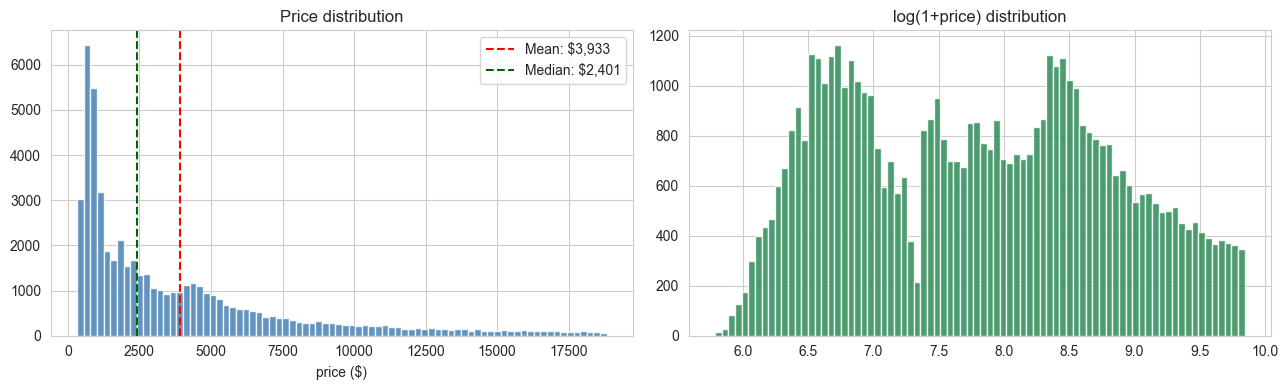

price skewness     : 1.62
log(price) skewness: 0.12


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(df["price"], bins=80, color="steelblue", edgecolor="white", alpha=0.85)
axes[0].axvline(df["price"].mean(), color="red", linestyle="--",
                label=f"Mean: ${df['price'].mean():,.0f}")
axes[0].axvline(df["price"].median(), color="darkgreen", linestyle="--",
                label=f"Median: ${df['price'].median():,.0f}")
axes[0].set_title("Price distribution"); axes[0].set_xlabel("price ($)")
axes[0].legend()
axes[1].hist(np.log1p(df["price"]), bins=80, color="seagreen", edgecolor="white", alpha=0.85)
axes[1].set_title("log(1+price) distribution")
plt.tight_layout(); plt.show()
print(f"price skewness     : {df['price'].skew():.2f}")
print(f"log(price) skewness: {np.log1p(df['price']).skew():.2f}")

## 6. Univariate — Numeric Features

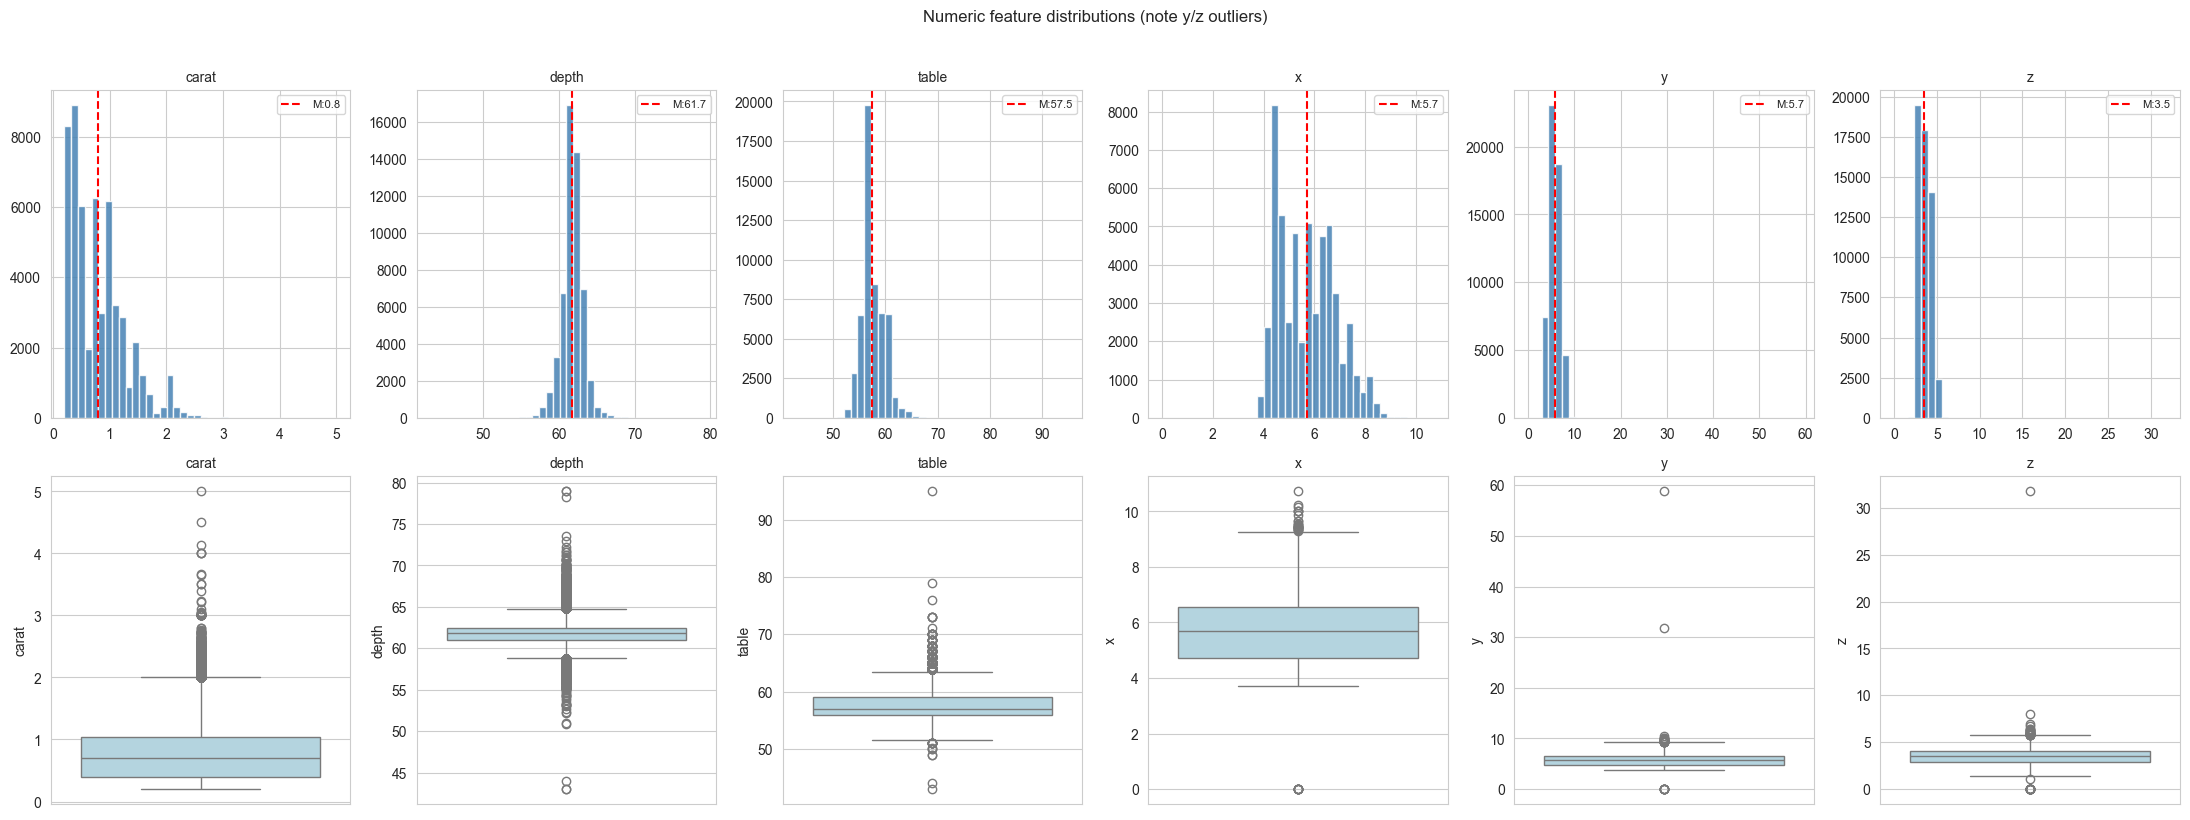

In [8]:
num_features = ["carat","depth","table","x","y","z"]
fig, axes = plt.subplots(2, 6, figsize=(22, 8))
for i, col in enumerate(num_features):
    df[col].hist(bins=40, color="steelblue", edgecolor="white", alpha=0.85, ax=axes[0,i])
    axes[0,i].axvline(df[col].mean(), color="red", linestyle="--",
                      label=f"M:{df[col].mean():.1f}")
    axes[0,i].set_title(col, fontsize=10); axes[0,i].legend(fontsize=8)
    sns.boxplot(y=df[col], ax=axes[1,i], color="lightblue")
    axes[1,i].set_title(col, fontsize=10)
plt.suptitle("Numeric feature distributions (note y/z outliers)", y=1.02)
plt.tight_layout(); plt.show()

## 7. Univariate — Categorical Features

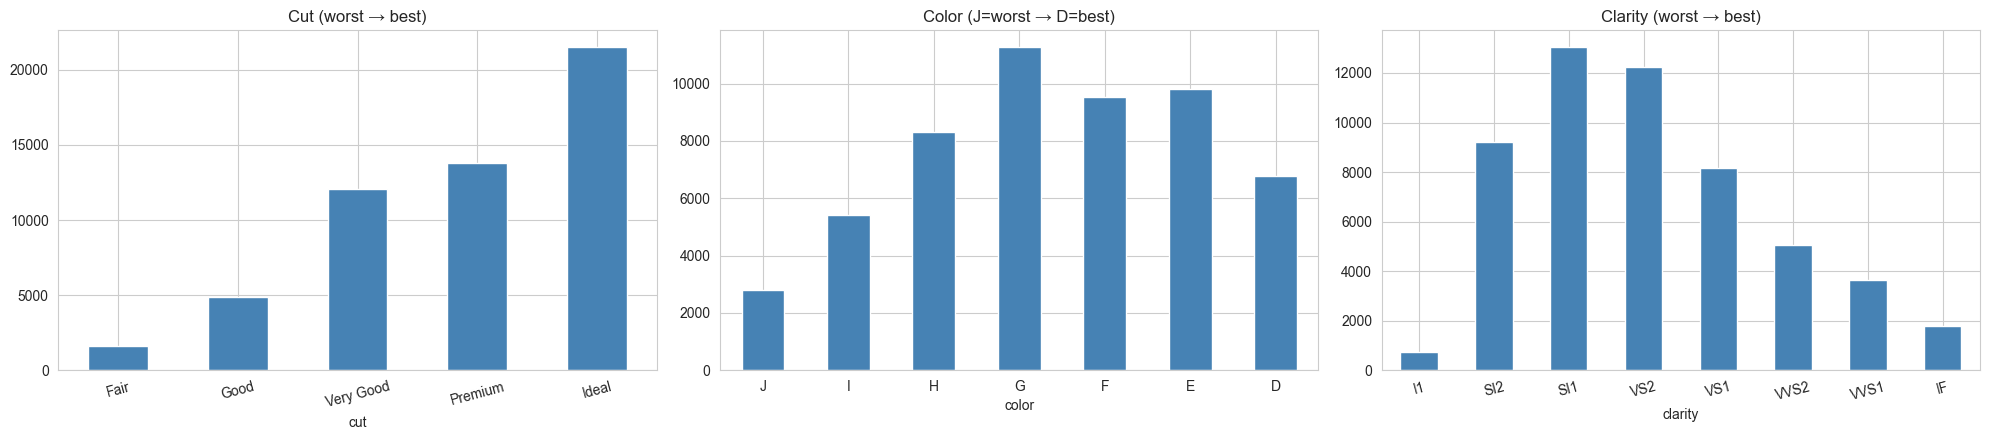

In [9]:
cut_order     = ["Fair","Good","Very Good","Premium","Ideal"]
color_order   = ["J","I","H","G","F","E","D"]
clarity_order = ["I1","SI2","SI1","VS2","VS1","VVS2","VVS1","IF"]

fig, axes = plt.subplots(1, 3, figsize=(20, 4.5))
df["cut"].value_counts().reindex(cut_order).plot(kind="bar", color="steelblue", ax=axes[0])
axes[0].set_title("Cut (worst → best)"); axes[0].tick_params(axis="x", rotation=15)
df["color"].value_counts().reindex(color_order).plot(kind="bar", color="steelblue", ax=axes[1])
axes[1].set_title("Color (J=worst → D=best)"); axes[1].tick_params(axis="x", rotation=0)
df["clarity"].value_counts().reindex(clarity_order).plot(kind="bar", color="steelblue", ax=axes[2])
axes[2].set_title("Clarity (worst → best)"); axes[2].tick_params(axis="x", rotation=15)
plt.tight_layout(); plt.show()

## 8. Bivariate — Numeric Features vs Price

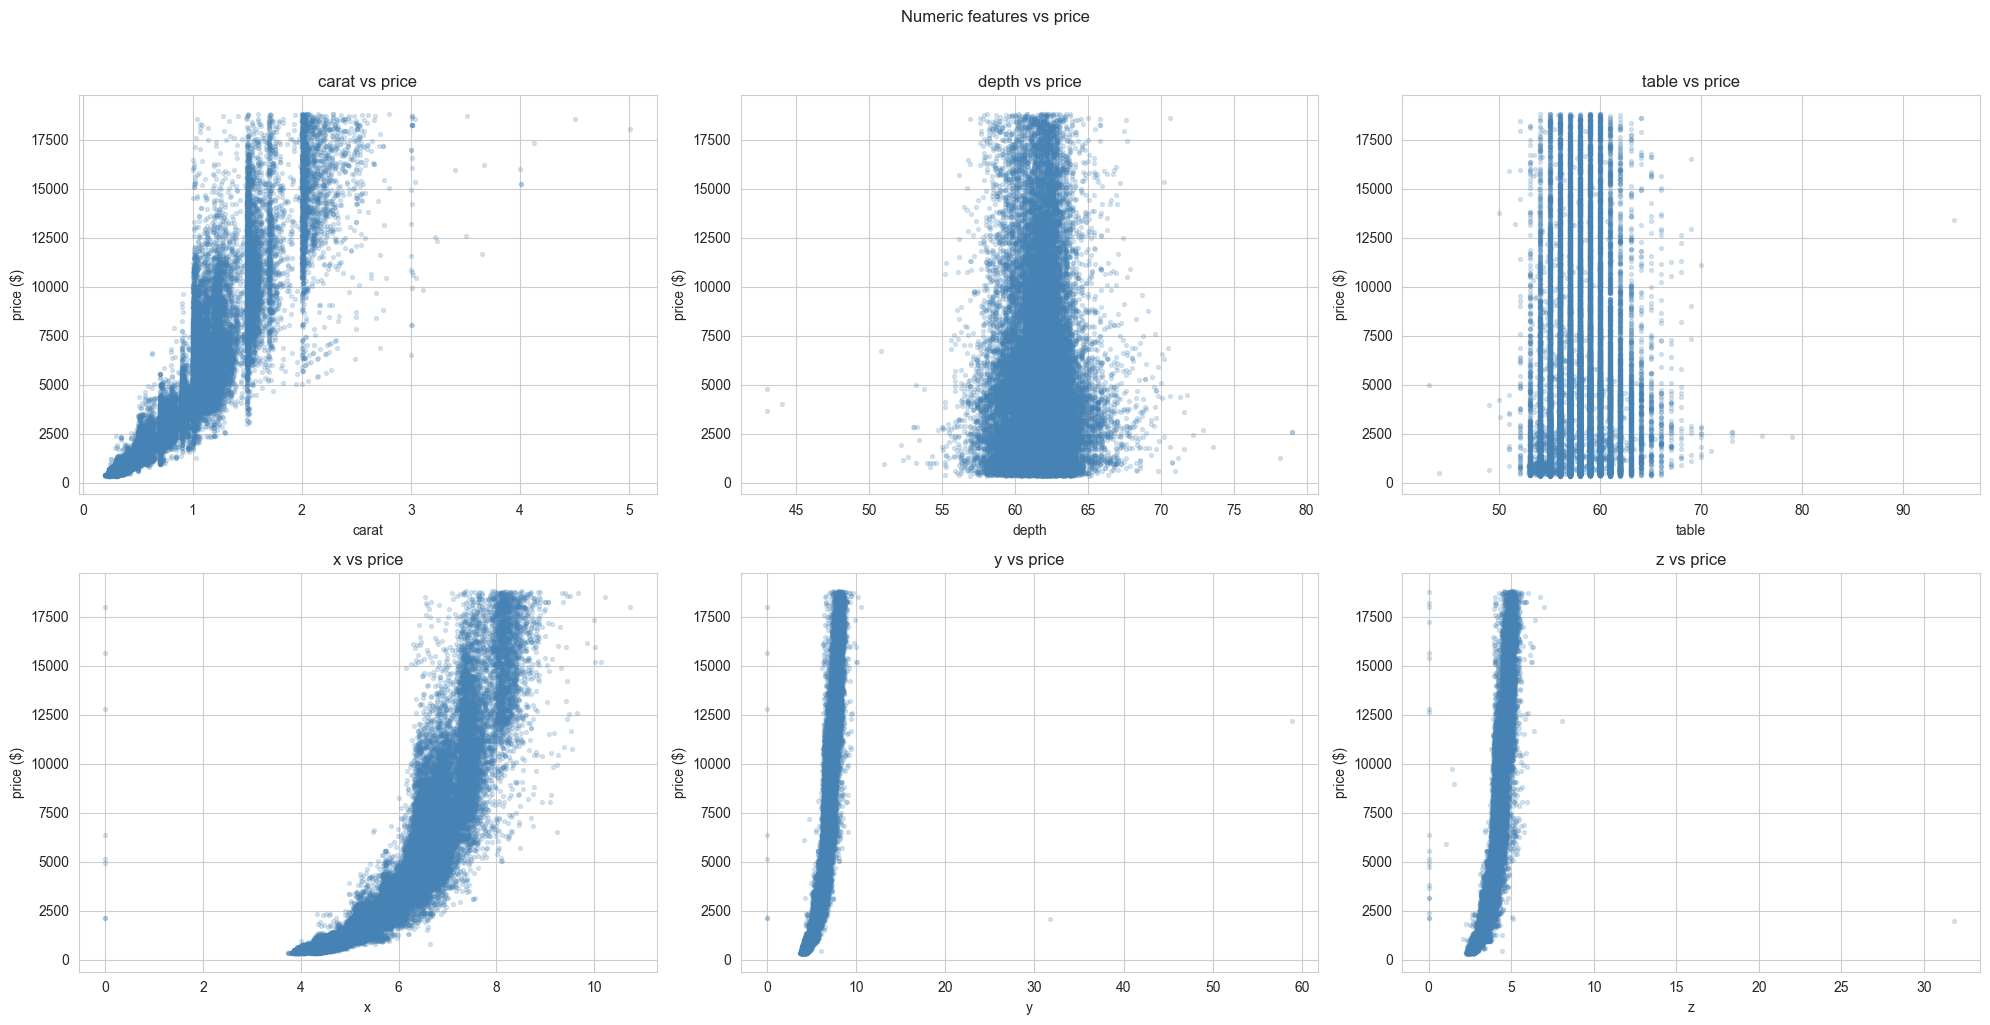

Pearson correlations with price:
carat    0.922
depth   -0.011
table    0.127
x        0.884
y        0.865
z        0.861
Name: price, dtype: float64


In [10]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()
for i, col in enumerate(num_features):
    axes[i].scatter(df[col], df["price"], alpha=0.2, color="steelblue", s=8)
    axes[i].set_xlabel(col); axes[i].set_ylabel("price ($)")
    axes[i].set_title(f"{col} vs price")
plt.suptitle("Numeric features vs price", y=1.02)
plt.tight_layout(); plt.show()
print("Pearson correlations with price:")
print(df[num_features + ["price"]].corr()["price"].drop("price").round(3))

## 9. Bivariate — Categorical Features vs Price

/var/folders/3t/st_qgzrd3957m1htwzrz0pkc0000gn/T/ipykernel_64664/3429141700.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="cut", y="price", data=df, palette="Set2", order=cut_order, ax=axes[0])
/var/folders/3t/st_qgzrd3957m1htwzrz0pkc0000gn/T/ipykernel_64664/3429141700.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="color", y="price", data=df, palette="Set2", order=color_order, ax=axes[1])
/var/folders/3t/st_qgzrd3957m1htwzrz0pkc0000gn/T/ipykernel_64664/3429141700.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="clarity"

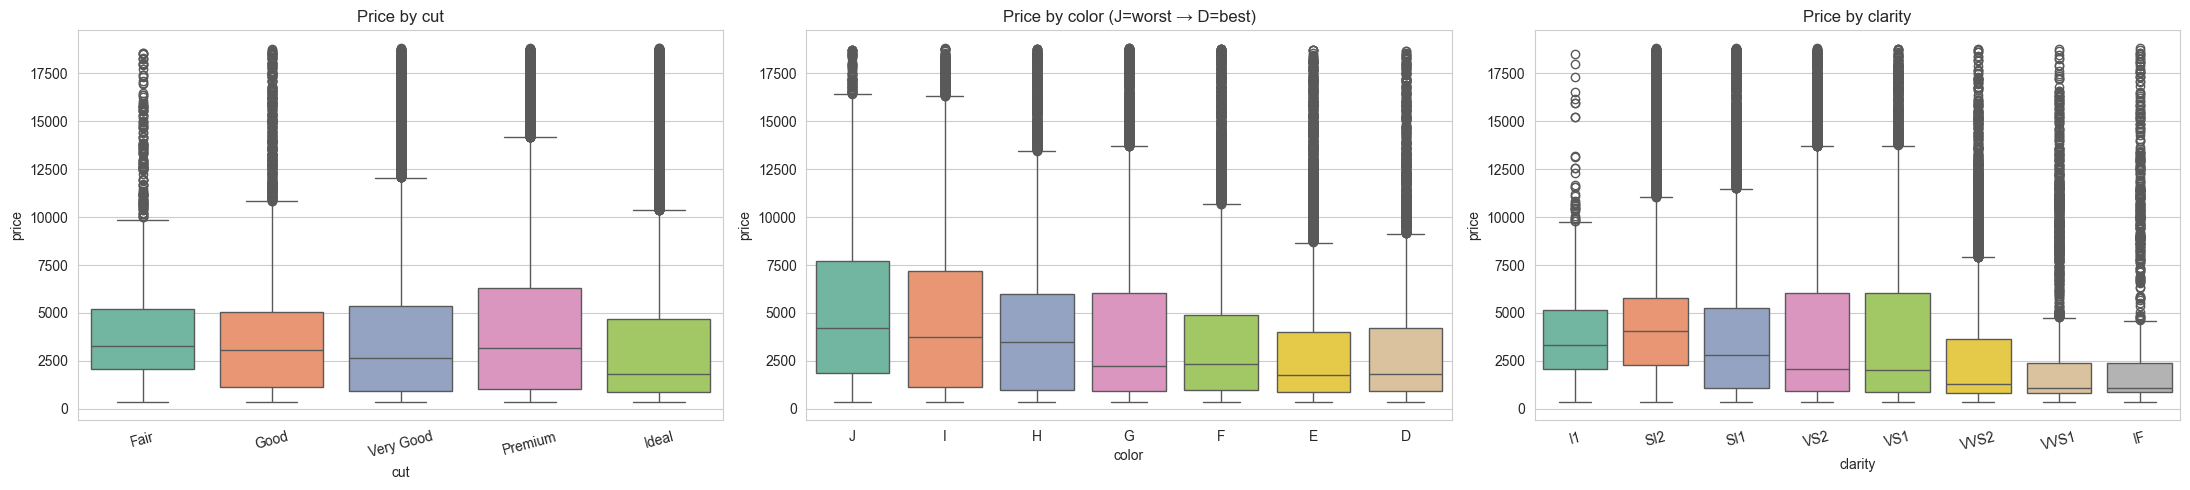

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(22, 5))
sns.boxplot(x="cut", y="price", data=df, palette="Set2", order=cut_order, ax=axes[0])
axes[0].set_title("Price by cut")
axes[0].tick_params(axis="x", rotation=15)
sns.boxplot(x="color", y="price", data=df, palette="Set2", order=color_order, ax=axes[1])
axes[1].set_title("Price by color (J=worst → D=best)")
sns.boxplot(x="clarity", y="price", data=df, palette="Set2", order=clarity_order, ax=axes[2])
axes[2].set_title("Price by clarity")
axes[2].tick_params(axis="x", rotation=15)
plt.tight_layout(); plt.show()

In [12]:
# Mean price per categorical level
for col, order in [("cut", cut_order), ("color", color_order), ("clarity", clarity_order)]:
    print(f"\nMean price by {col}:")
    print(df.groupby(col)["price"].mean().reindex(order).round(0))


Mean price by cut:
cut
Fair         4359.0
Good         3929.0
Very Good    3982.0
Premium      4584.0
Ideal        3458.0
Name: price, dtype: float64

Mean price by color:
color
J    5324.0
I    5092.0
H    4487.0
G    3999.0
F    3725.0
E    3077.0
D    3170.0
Name: price, dtype: float64

Mean price by clarity:
clarity
I1      3924.0
SI2     5063.0
SI1     3996.0
VS2     3925.0
VS1     3839.0
VVS2    3284.0
VVS1    2523.0
IF      2865.0
Name: price, dtype: float64


## 10. Carat × Cut Interaction

Carat is the dominant predictor, but cut quality matters more for larger diamonds.

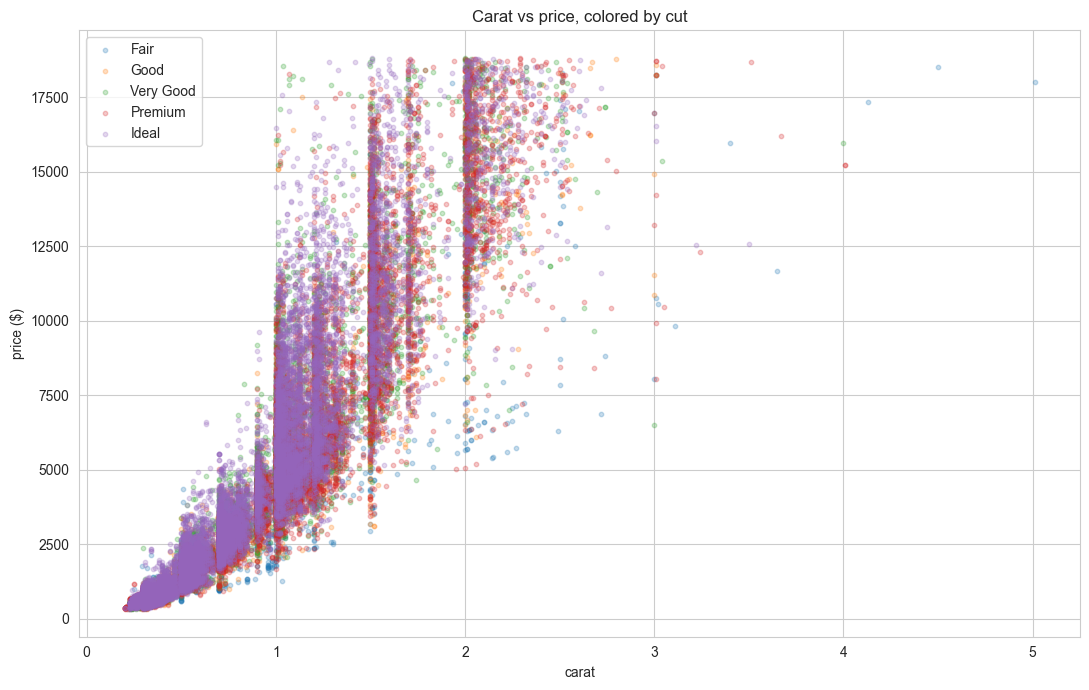

In [13]:
plt.figure(figsize=(11, 7))
for cut in cut_order:
    sub = df[df["cut"] == cut]
    plt.scatter(sub["carat"], sub["price"], alpha=0.25, s=10, label=cut)
plt.xlabel("carat"); plt.ylabel("price ($)")
plt.title("Carat vs price, colored by cut")
plt.legend()
plt.tight_layout(); plt.show()

## 11. Correlation Analysis

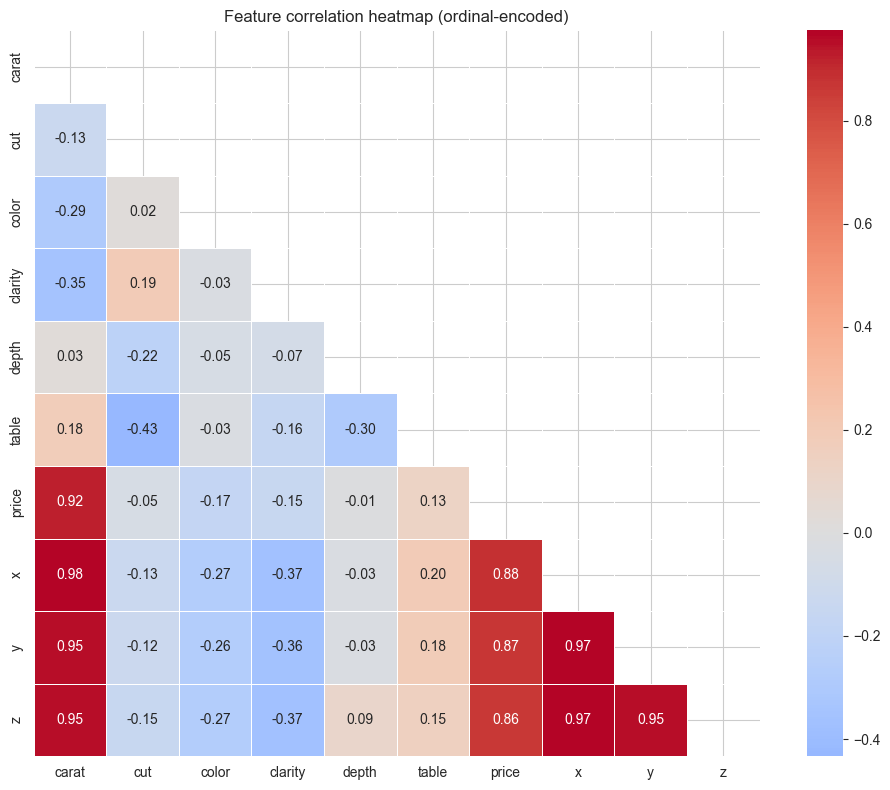

In [14]:
df_corr = df.copy()
df_corr["cut"]     = df_corr["cut"].map({k:i for i,k in enumerate(cut_order)})
df_corr["color"]   = df_corr["color"].map({k:i for i,k in enumerate(color_order)})
df_corr["clarity"] = df_corr["clarity"].map({k:i for i,k in enumerate(clarity_order)})
plt.figure(figsize=(10, 8))
corr = df_corr.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5)
plt.title("Feature correlation heatmap (ordinal-encoded)")
plt.tight_layout(); plt.show()

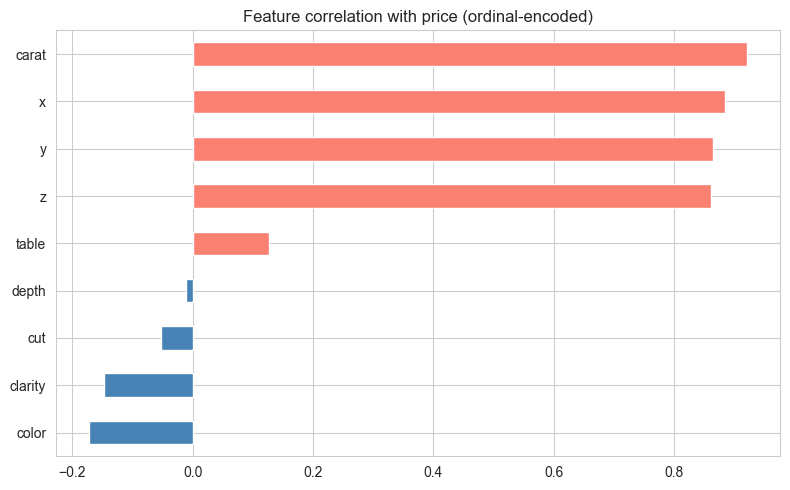

carat      0.922
x          0.884
y          0.865
z          0.861
table      0.127
depth     -0.011
cut       -0.053
clarity   -0.147
color     -0.173
Name: price, dtype: float64


In [15]:
target_corr = df_corr.corr()["price"].drop("price").sort_values(ascending=False)
plt.figure(figsize=(8, 5))
target_corr.plot(kind="barh",
                 color=["salmon" if x > 0 else "steelblue" for x in target_corr])
plt.title("Feature correlation with price (ordinal-encoded)")
plt.gca().invert_yaxis()
plt.tight_layout(); plt.show()
print(target_corr.round(3))

## 12. Pair Plot — Top Numeric Predictors

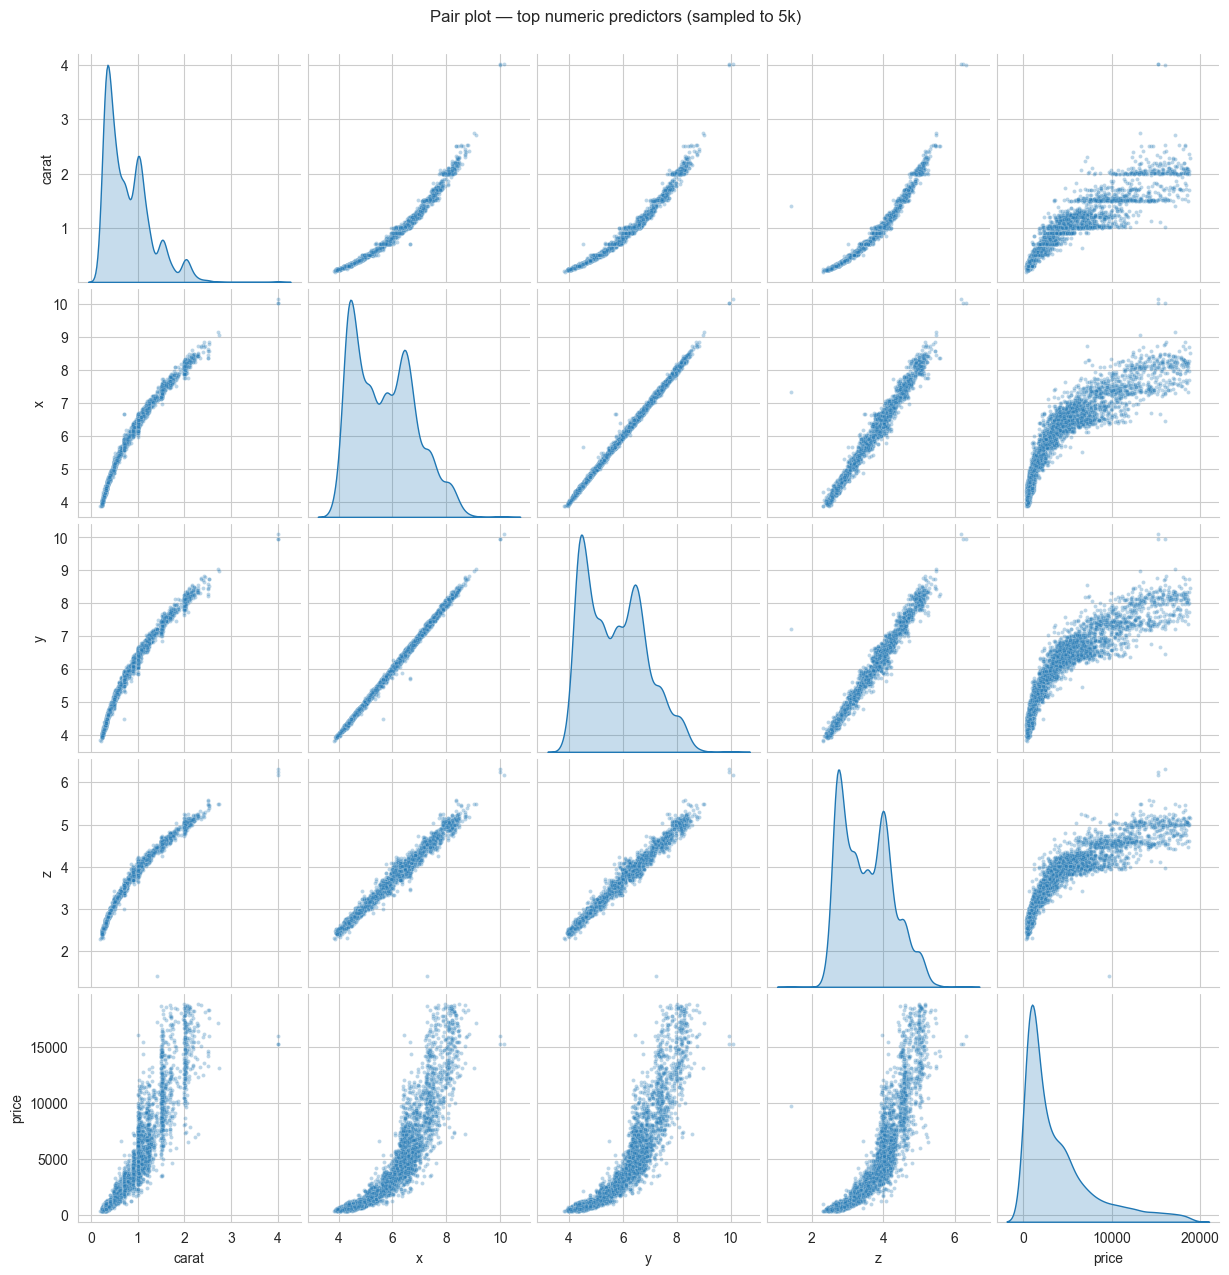

In [16]:
plot_df = df_corr.sample(n=5000, random_state=42)[["carat","x","y","z","price"]]
sns.pairplot(plot_df, diag_kind="kde", plot_kws={"alpha": 0.3, "s": 8})
plt.suptitle("Pair plot — top numeric predictors (sampled to 5k)", y=1.02)
plt.show()

## 13. Key EDA Findings

| # | Finding |
|---|--------|
| 1 | **Carat dominates** (r ≈ 0.92) — diamond mass alone explains most of the price |
| 2 | **x, y, z are nearly perfect proxies for carat** (each r > 0.86 with price; r > 0.95 between themselves and carat) — multicollinearity is severe |
| 3 | **Price is heavily right-skewed** (skewness ≈ 1.6); a log transform brings it close to normal |
| 4 | **Cut, color, clarity are surprisingly weakly correlated with price** in raw form — because larger diamonds tend to have *worse* cut/color/clarity, and carat dominates the gross price |
| 5 | **20 rows have x/y/z == 0** — physically impossible; drop them in cleaning |
| 6 | **`y` and `z` have extreme outliers** (max ≈ 58 mm and 31 mm) — likely data-entry errors; the 0 rows go away with the same filter |
| 7 | **Within a fixed carat, color and clarity matter a lot** — Simpson's-paradox style: their marginal effect is hidden by carat correlation in the raw data |